In [1]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

In [3]:
import cooltools
import cooler

cool_file = "CustardPyResults_Hi-C/Cooler_hg38/Control/cool/Control.multires.cool"

# 10 kb is a resolution at which one can clearly see "dots":
binsize = 1000000
# Open cool file with Micro-C data:
clr = cooler.Cooler(f'{cool_file}::/resolutions/{binsize}')

In [4]:
### to print chromosomes and binsize for this cooler
print(f'chromosomes: {clr.chromnames}, binsize: {clr.binsize}')

### to make a list of chromosome start/ends in bins:
chromstarts = []
for i in clr.chromnames:
    print(f'{i} : {clr.extent(i)}')
    chromstarts.append(clr.extent(i)[0])

chromosomes: ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX', 'chrY', 'chrM'], binsize: 1000000
chr1 : (0, 249)
chr2 : (249, 492)
chr3 : (492, 691)
chr4 : (691, 882)
chr5 : (882, 1064)
chr6 : (1064, 1235)
chr7 : (1235, 1395)
chr8 : (1395, 1541)
chr9 : (1541, 1680)
chr10 : (1680, 1814)
chr11 : (1814, 1950)
chr12 : (1950, 2084)
chr13 : (2084, 2199)
chr14 : (2199, 2307)
chr15 : (2307, 2409)
chr16 : (2409, 2500)
chr17 : (2500, 2584)
chr18 : (2584, 2665)
chr19 : (2665, 2724)
chr20 : (2724, 2789)
chr21 : (2789, 2836)
chr22 : (2836, 2887)
chrX : (2887, 3044)
chrY : (3044, 3102)
chrM : (3102, 3103)


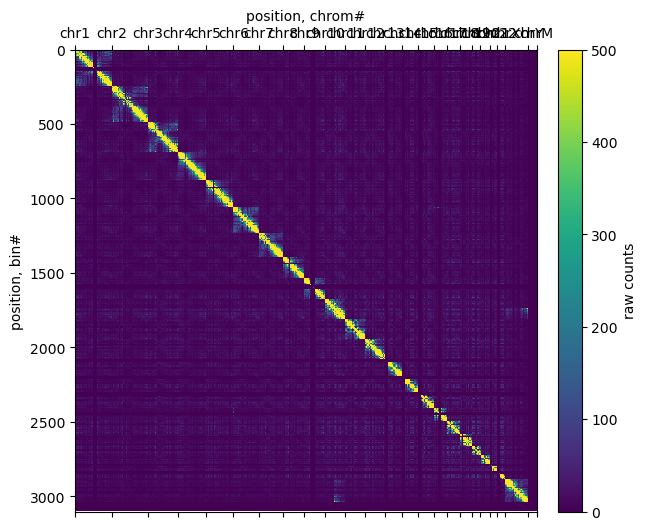

In [14]:
# raw counts

f, ax = plt.subplots(figsize=(7,6))

im = ax.matshow((clr.matrix(balance=False)[:]),vmax=500);

plt.colorbar(im ,fraction=0.046, pad=0.04, label='raw counts')

ax.set(xticks=chromstarts, xticklabels=clr.chromnames,
       xlabel='position, chrom#', ylabel='position, bin#')

ax.xaxis.set_label_position('top')

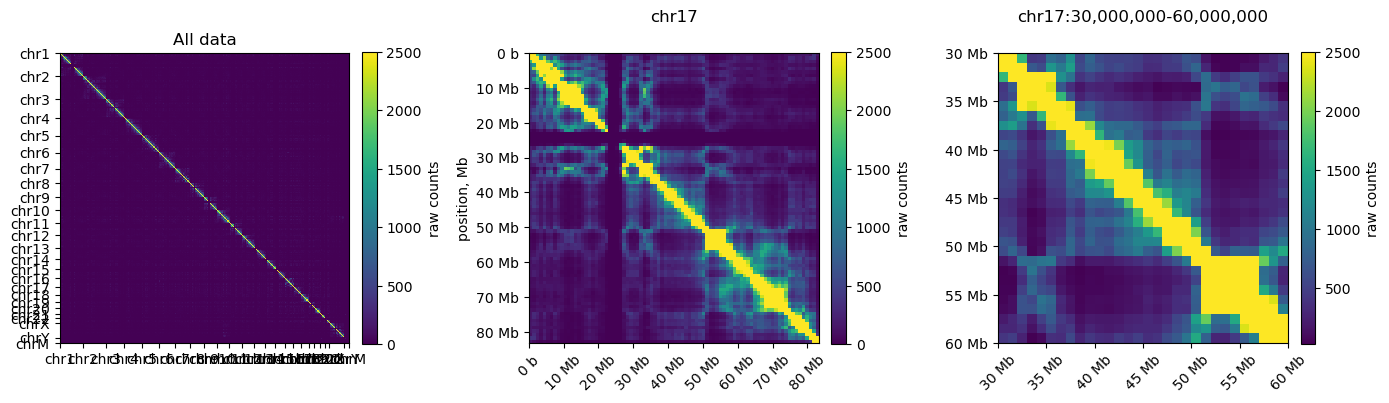

In [6]:
# to plot ticks in terms of megabases we use the EngFormatter
# https://matplotlib.org/gallery/api/engineering_formatter.html
from matplotlib.ticker import EngFormatter
bp_formatter = EngFormatter('b')

def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

f, axs = plt.subplots(
    figsize=(14,4),
    ncols=3)

ax = axs[0]
im = ax.matshow(clr.matrix(balance=False)[:], vmax=2500);
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='raw counts');
ax.set_xticks(chromstarts)
ax.set_xticklabels(clr.chromnames)
ax.set_yticks(chromstarts)
ax.set_yticklabels(clr.chromnames)
ax.xaxis.tick_bottom()
ax.set_title('All data')

ax = axs[1]
im = ax.matshow(
    clr.matrix(balance=False).fetch('chr17'),
    vmax=2500,
    extent=(0,clr.chromsizes['chr17'], clr.chromsizes['chr17'], 0)
);
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='raw counts');
ax.set_title('chr17', y=1.08)
ax.set_ylabel('position, Mb')
format_ticks(ax)

ax = axs[2]
start, end = 30_000_000, 60_000_000
region = ('chr17', start, end)
im = ax.matshow(
    clr.matrix(balance=False).fetch(region),
    vmax=2500,
    extent=(start, end, end, start)
);
ax.set_title(f'chr17:{start:,}-{end:,}', y=1.08)
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='raw counts');
format_ticks(ax)
plt.tight_layout()

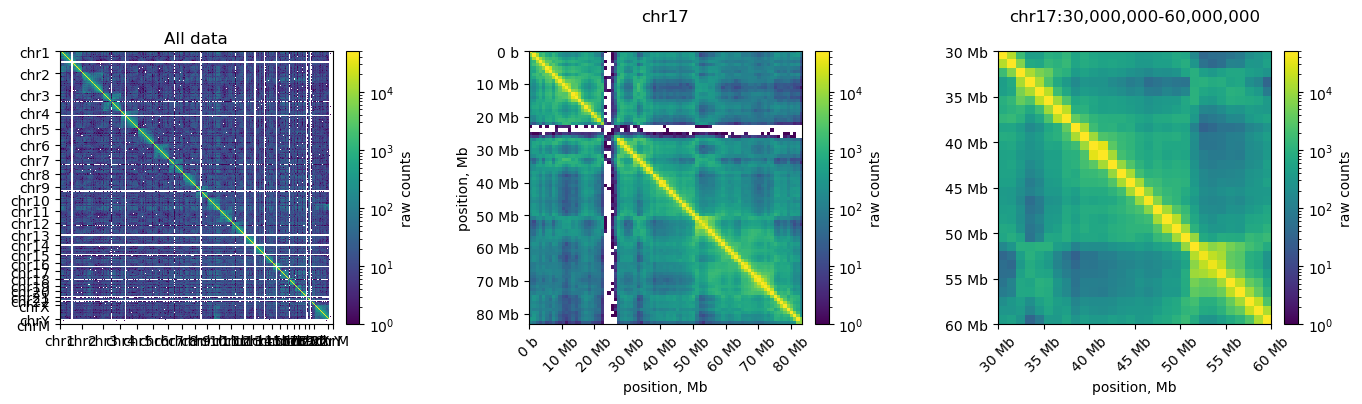

In [7]:
from matplotlib.colors import LogNorm

f, axs = plt.subplots(
    figsize=(14,4),
    ncols=3)
bp_formatter = EngFormatter('b')
norm = LogNorm(vmax=50_000)

ax = axs[0]
im = ax.matshow(
    clr.matrix(balance=False)[:],
    norm=norm,
)
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='raw counts');
ax.set_xticks(chromstarts)
ax.set_xticklabels(clr.chromnames)
ax.set_yticks(chromstarts)
ax.set_yticklabels(clr.chromnames)
ax.xaxis.tick_bottom()
ax.set_title('All data')

ax = axs[1]
im = ax.matshow(
    clr.matrix(balance=False).fetch('chr17'),
    norm=norm,
    extent=(0,clr.chromsizes['chr17'], clr.chromsizes['chr17'], 0)
);
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='raw counts');
ax.set_title('chr17', y=1.08)
ax.set(ylabel='position, Mb', xlabel='position, Mb')
format_ticks(ax)

ax = axs[2]
start, end = 30_000_000, 60_000_000
region = ('chr17', start, end)
im = ax.matshow(
    clr.matrix(balance=False).fetch(region),
    norm=norm,
    extent=(start, end, end, start)
);
ax.set_title(f'chr17:{start:,}-{end:,}', y=1.08)
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='raw counts');
ax.set(xlabel='position, Mb')
format_ticks(ax)
plt.tight_layout()

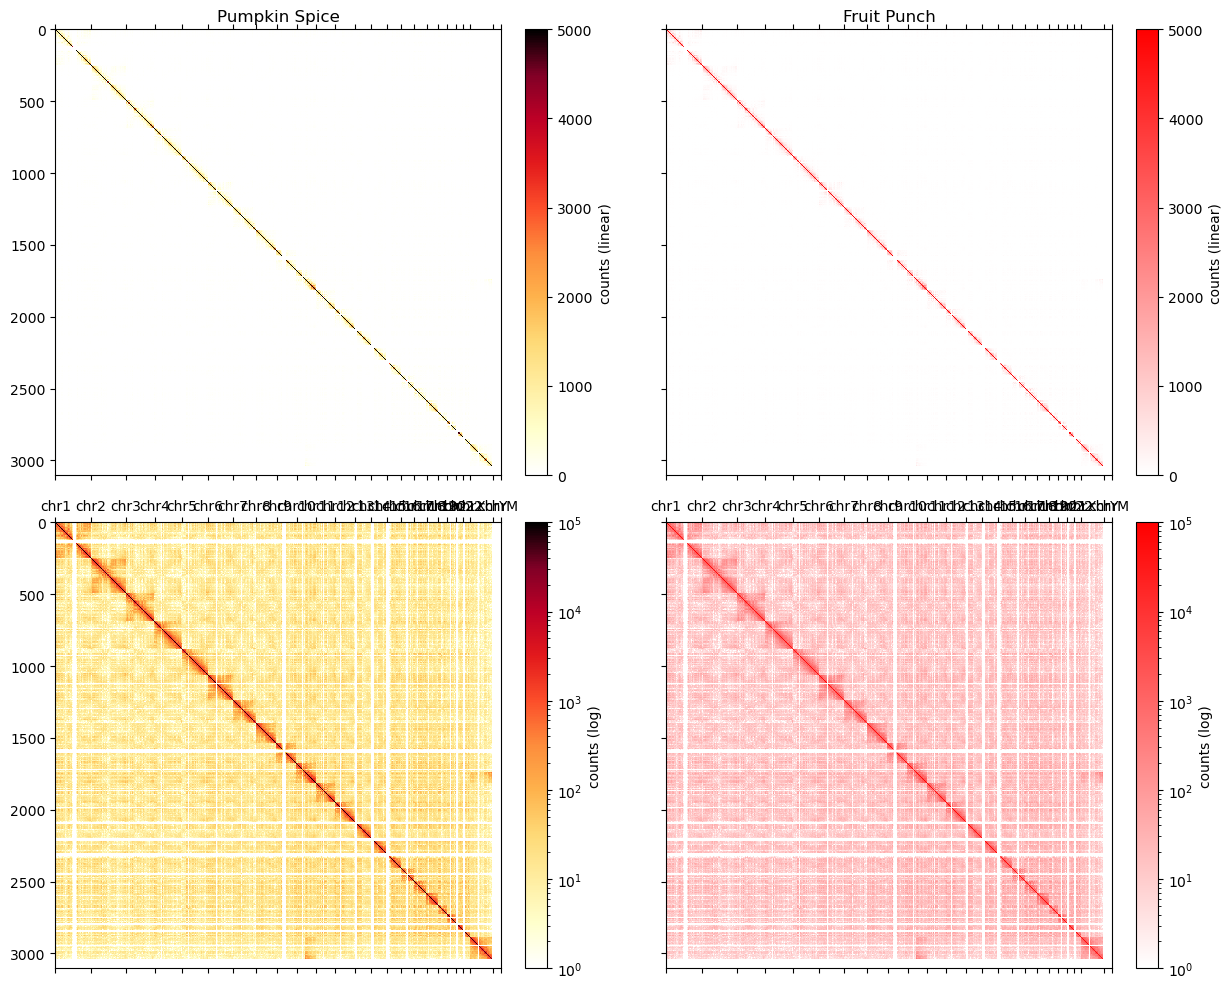

In [8]:
import cooltools.lib.plotting

vmax = 5000
norm = LogNorm(vmin=1, vmax=100_000)
fruitpunch = sns.blend_palette(['white', 'red'], as_cmap=True)

f, axs = plt.subplots(
    figsize=(13, 10),
    nrows=2,
    ncols=2,
    sharex=True, sharey=True)

ax = axs[0, 0]
ax.set_title('Pumpkin Spice')
im = ax.matshow(clr.matrix(balance=False)[:], vmax=vmax, cmap='fall');
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='counts (linear)');
plt.xticks(chromstarts,clr.chromnames);

ax = axs[0, 1]
ax.set_title('Fruit Punch')
im3 = ax.matshow(clr.matrix(balance=False)[:], vmax=vmax, cmap=fruitpunch);
plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04, label='counts (linear)');
plt.xticks(chromstarts,clr.chromnames);

ax = axs[1, 0]
im = ax.matshow(clr.matrix(balance=False)[:], norm=norm, cmap='fall');
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='counts (log)');
plt.xticks(chromstarts,clr.chromnames);

ax = axs[1, 1]
im3 = ax.matshow(clr.matrix(balance=False)[:], norm=norm, cmap=fruitpunch);
plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04, label='counts (log)');
plt.xticks(chromstarts,clr.chromnames);

plt.tight_layout()

In [9]:
clr.matrix(balance=False).fetch('chr17')

array([[60442,  7182,  1698, ...,   111,   365,   138],
       [ 7182, 74297, 12867, ...,   311,   369,    78],
       [ 1698, 12867, 77031, ...,   163,   175,    33],
       ...,
       [  111,   311,   163, ..., 61097,  7601,   364],
       [  365,   369,   175, ...,  7601, 64432,  7613],
       [  138,    78,    33, ...,   364,  7613,  8633]], dtype=int32)

In [10]:
clr.matrix(balance=True).fetch('chr17')

array([[1.03416468, 0.10444573, 0.02103652, ..., 0.00219396, 0.00609508,
               nan],
       [0.10444573, 0.91835582, 0.13549023, ..., 0.00522468, 0.0052373 ,
               nan],
       [0.02103652, 0.13549023, 0.69101452, ..., 0.0023328 , 0.00211597,
               nan],
       ...,
       [0.00219396, 0.00522468, 0.0023328 , ..., 1.39501422, 0.14662607,
               nan],
       [0.00609508, 0.0052373 , 0.00211597, ..., 0.14662607, 1.05008335,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]])

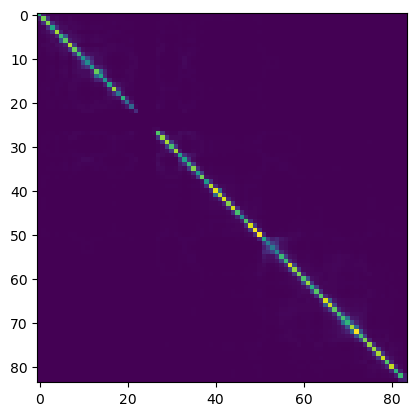

In [11]:
plt.imshow(clr.matrix(balance=False).fetch('chr17'))

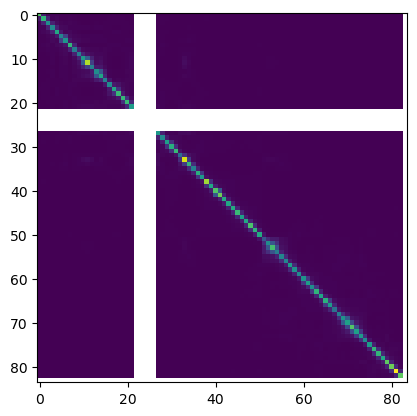

In [12]:
plt.imshow(clr.matrix(balance=True).fetch('chr17'))

In [13]:
array = clr.matrix(balance=True).fetch('chr17')
array

array([[1.03416468, 0.10444573, 0.02103652, ..., 0.00219396, 0.00609508,
               nan],
       [0.10444573, 0.91835582, 0.13549023, ..., 0.00522468, 0.0052373 ,
               nan],
       [0.02103652, 0.13549023, 0.69101452, ..., 0.0023328 , 0.00211597,
               nan],
       ...,
       [0.00219396, 0.00522468, 0.0023328 , ..., 1.39501422, 0.14662607,
               nan],
       [0.00609508, 0.0052373 , 0.00211597, ..., 0.14662607, 1.05008335,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]])

In [25]:
array.shape[0]


84

In [16]:
clr.chromsizes['chr17']

83257441

In [27]:
index = np.arange(array.shape[0]) * binsize
index

array([       0,  1000000,  2000000,  3000000,  4000000,  5000000,
        6000000,  7000000,  8000000,  9000000, 10000000, 11000000,
       12000000, 13000000, 14000000, 15000000, 16000000, 17000000,
       18000000, 19000000, 20000000, 21000000, 22000000, 23000000,
       24000000, 25000000, 26000000, 27000000, 28000000, 29000000,
       30000000, 31000000, 32000000, 33000000, 34000000, 35000000,
       36000000, 37000000, 38000000, 39000000, 40000000, 41000000,
       42000000, 43000000, 44000000, 45000000, 46000000, 47000000,
       48000000, 49000000, 50000000, 51000000, 52000000, 53000000,
       54000000, 55000000, 56000000, 57000000, 58000000, 59000000,
       60000000, 61000000, 62000000, 63000000, 64000000, 65000000,
       66000000, 67000000, 68000000, 69000000, 70000000, 71000000,
       72000000, 73000000, 74000000, 75000000, 76000000, 77000000,
       78000000, 79000000, 80000000, 81000000, 82000000, 83000000])

In [28]:
df = pd.DataFrame(array, index=index, columns=index)
df.head()

,0,1000000,2000000,3000000,4000000,5000000,6000000,7000000,8000000,9000000,...,74000000,75000000,76000000,77000000,78000000,79000000,80000000,81000000,82000000,83000000
0,1.034165,0.104446,0.021037,0.013817,0.012583,0.008948,0.007555,0.007781,0.006527,0.005293,...,0.001422,0.001840,0.002101,0.001991,0.002102,0.002449,0.002519,0.002194,0.006095,NaN
1000000,0.104446,0.918356,0.135490,0.016155,0.023717,0.008773,0.005654,0.014376,0.006815,0.002827,...,0.001030,0.003236,0.003428,0.001974,0.002244,0.001544,0.003117,0.005225,0.005237,NaN
2000000,0.021037,0.135490,0.691015,0.128622,0.038389,0.018348,0.013997,0.017092,0.011941,0.007243,...,0.001325,0.002183,0.002048,0.001331,0.001559,0.001374,0.002250,0.002333,0.002116,NaN
3000000,0.013817,0.016155,0.128622,0.659316,0.139556,0.035605,0.031755,0.014199,0.015793,0.014799,...,0.001505,0.000948,0.001050,0.000968,0.001175,0.001284,0.000994,0.001120,0.001169,NaN
4000000,0.012583,0.023717,0.038389,0.139556,0.842827,0.095954,0.021374,0.031670,0.013613,0.005629,...,0.001210,0.002768,0.002197,0.001310,0.001603,0.001499,0.002334,0.002686,0.002723,NaN


In [ ]:
df.to_csv(outputfile, sep='\t', compression='gzip')